A testing file to check the aliasing and leakage of the fft when computing the Fresnel diffraction

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys

sys.path.insert(0, '../../synthPy_restructured')

import domain as d
import beam as beam_initialiser
import propagator as p
import testing_for_fft as xray

In [3]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3

n_cells = 100

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])

domain = d.ScalarDomain(lengths, n_cells) # B_on = False by default


In [4]:
wl = 0.1e-9 #define laser wavelength

# initialise beam
Np = 100000  # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

initial_rays = beam_initialiser.Beam(Np, beam_size, divergence, ne_extent, probing_direction, wl, beam_type)
tracer = p.Propagator(domain, initial_rays, inv_brems = False, x_ray = True, phaseshift = True, refrac_field = False, elec_density = True)

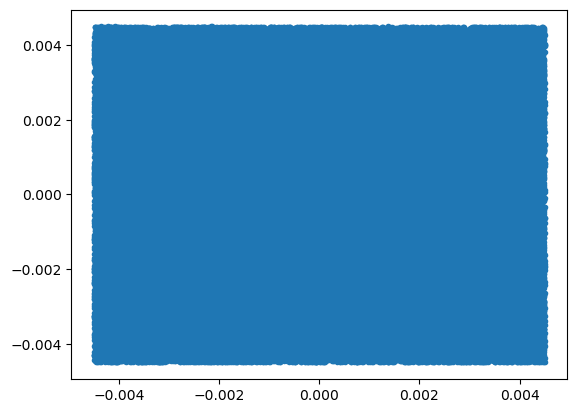

In [5]:
x_pos = (2*np.random.rand(Np)-1.0)*beam_size
y_pos = (2*np.random.rand(Np)-1.0)*beam_size

jones_vector_fake = np.zeros((4, Np))
jones_vector_fake[0] = x_pos
jones_vector_fake[2] = y_pos
amplitudes = np.full((Np, 2), 1)
phases = np.zeros((Np, 2))
plt.plot(jones_vector_fake[0], jones_vector_fake[2], ".")


Fresnel Number: 100000000.0000
Fresnel Number: 199600.7984
Fresnel Number: 99900.0999
Fresnel Number: 66622.2518
Fresnel Number: 49975.0125
Fresnel Number: 39984.0064


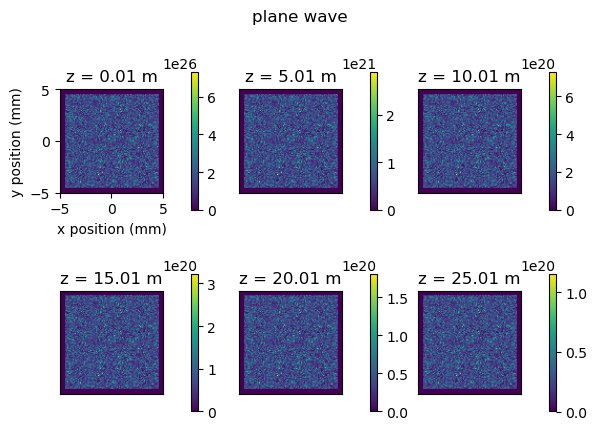

In [11]:
a = 2
b = 3
fig, axs = plt.subplots(a,b)
fig.suptitle("plane wave")
fig.subplots_adjust(wspace = 0.3)
axes = axs.flatten()
final_fields = []

for i in range (0,a*b):
    final_field, FX, FY, U0_ft = xray.propagate(Propagator = tracer, jones_vector = jones_vector_fake, amplitudes = amplitudes, phases = phases,  z = 0.01 + 5*i)
    final_fields.append(np.absolute(final_field)**2)

images = []
counter = 0

for ax, data in zip(axs.flatten(), final_fields):
    im = ax.imshow(data, extent = (-5, 5, -5, 5), cmap = "viridis")
    images.append(im)
    if counter == 0:
        ax.set_xlabel("x position (mm)")
        ax.set_ylabel("y position (mm)")
    else:
        ax.set_xticks([])  # Remove x-axis ticks
        ax.set_yticks([])  # Remove y-axis ticks
    ax.set_title(f"z = {(0.01 + 5*counter):.2f} m")
    fig.colorbar(im, ax = ax, fraction = .05, pad = 0.2)
    counter += 1
U0_ft1 = np.absolute(U0_ft)

#im_ft = ax1.imshow(U0_ft1, norm = colors.LogNorm(vmin = U0_ft1.min(), vmax = U0_ft1.max()), extent = (FX.min(), FX.max(), FY.min(), FY.max()))
 
#plt.savefig("../../../test.png",dpi=800, bbox_inches='tight', pad_inches=0.1)

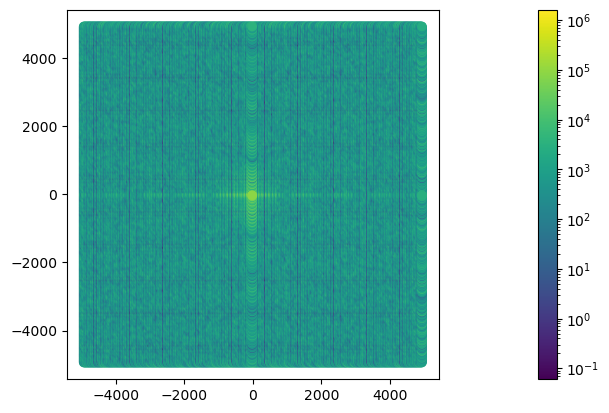

In [13]:
im_ft = plt.scatter(FX, FY, c = U0_ft1, norm = colors.LogNorm())
plt.colorbar(im_ft, fraction = .05, pad = 0.2)